In [33]:
%pip install pandas numpy seaborn matplotlib scikit-learn jupyter imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [34]:
# Importaciones básicas para KNN
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
from sklearn.cluster import KMeans
# Importación del algoritmo KNN
from sklearn.neighbors import KNeighborsClassifier

# Opcional: para división de datos y evaluación
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [ ]:
df_orig = pd.read_csv('data/raw/housing.csv')

In [36]:
df_orig.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [37]:
df= df_orig[['Latitude','Longitude','MedInc']]

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Latitude   20640 non-null  float64
 1   Longitude  20640 non-null  float64
 2   MedInc     20640 non-null  float64
dtypes: float64(3)
memory usage: 483.9 KB


In [39]:
df.describe()

,Latitude,Longitude,MedInc
count,20640.000000,20640.000000,20640.000000
mean,35.631861,-119.569704,3.870671
std,2.135952,2.003532,1.899822
min,32.540000,-124.350000,0.499900
25%,33.930000,-121.800000,2.563400
50%,34.260000,-118.490000,3.534800
75%,37.710000,-118.010000,4.743250
max,41.950000,-114.310000,15.000100


In [40]:
features = ['Latitude', 'Longitude', 'MedInc']

In [41]:
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

In [42]:
df_train.shape, df_test.shape

((16512, 3), (4128, 3))

In [43]:
housing_km = KMeans(n_clusters=6, random_state=42, n_init=10)
housing_km.fit(df_train[features])

KMeans(n_clusters=6, n_init=10, random_state=42)

In [44]:
df_train = df_train.copy() 
df_test = df_test.copy()

In [45]:
df_train['Cluster'] = housing_km.labels_
df_test['Cluster'] = housing_km.predict(df_test[features])

In [46]:
housing_km.labels_

array([2, 2, 0, ..., 2, 5, 4])

In [47]:
df_train['Cluster'] = housing_km.labels_

In [48]:
df_train.head()

,Latitude,Longitude,MedInc,Cluster
14196,32.71,-117.03,3.2596,2
8267,33.77,-118.16,3.8125,2
17445,34.66,-120.48,4.1563,0
14265,32.69,-117.11,1.9425,2
2271,36.78,-119.80,3.5542,0


In [49]:
df_train.columns

Index(['Latitude', 'Longitude', 'MedInc', 'Cluster'], dtype='object')

In [50]:
df_train['Cluster'].value_counts().sort_index()

Cluster
0    1348
1     342
2    5628
3    3024
4    3919
5    2251
Name: count, dtype: int64

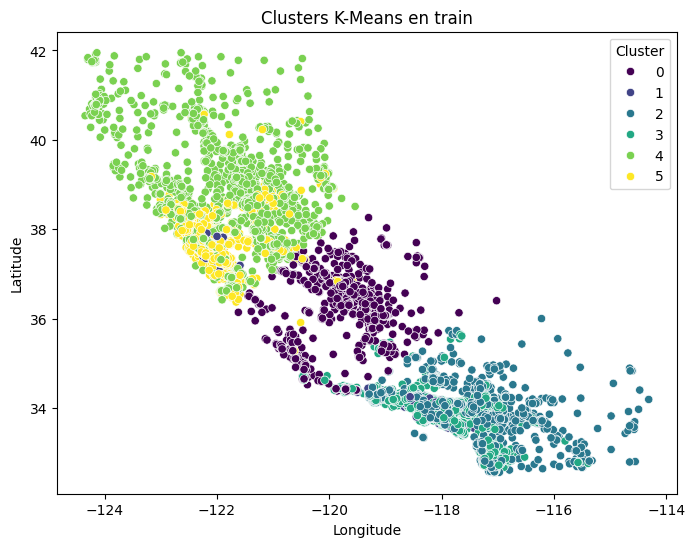

In [51]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_train,
    x='Longitude',
    y='Latitude',
    hue='Cluster',
    palette='viridis'
)
plt.title('Clusters K-Means en train')
plt.show()

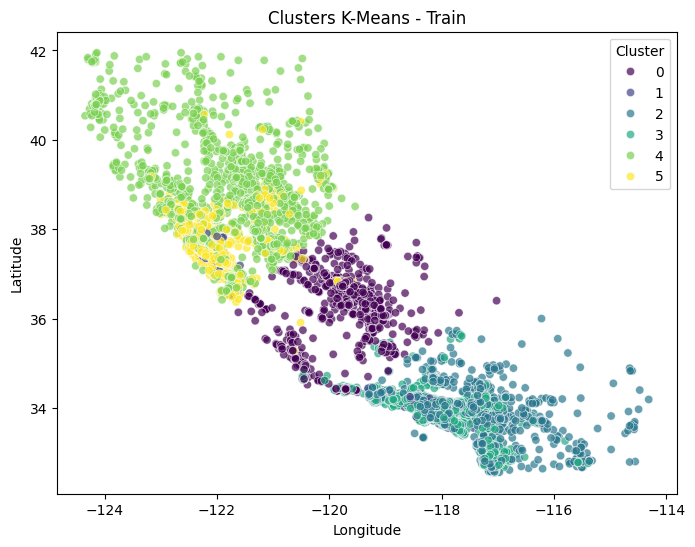

In [52]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_train,
    x='Longitude',
    y='Latitude',
    hue='Cluster',
    palette='viridis',
    alpha=0.7
)
plt.title('Clusters K-Means - Train')
plt.show()

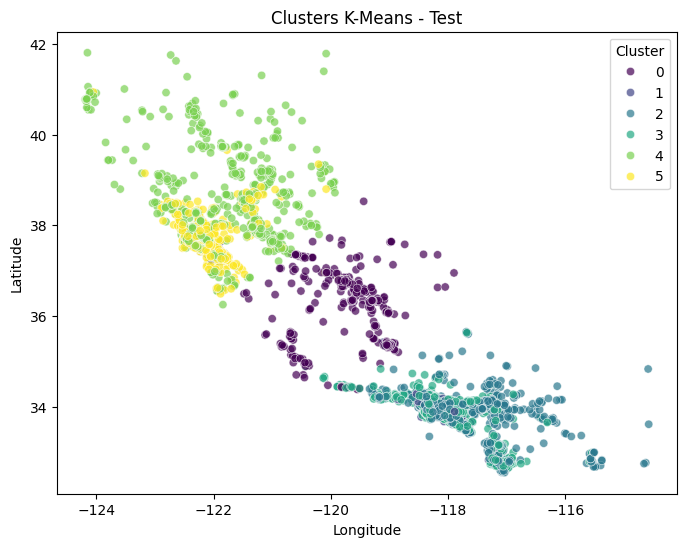

In [53]:
df_test['Cluster'] = housing_km.predict(df_test[features])

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_test,
    x='Longitude',
    y='Latitude',
    hue='Cluster',
    palette='viridis',
    alpha=0.7
)
plt.title('Clusters K-Means - Test')
plt.show()

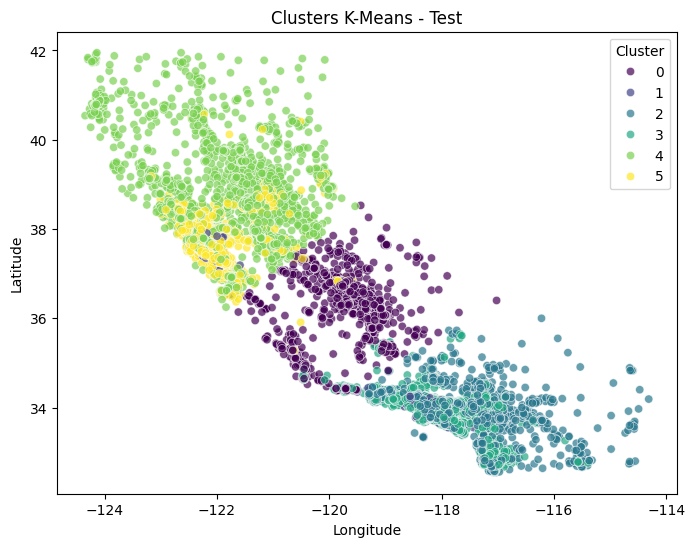

In [54]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pd.concat([df_test, df_train]),
    x='Longitude',
    y='Latitude',
    hue='Cluster',
    palette='viridis',
    alpha=0.7
)
plt.title('Clusters K-Means - Test')
plt.show()

In [55]:
# Ver los nombres de las columnas que recibió el modelo
print(housing_km.feature_names_in_)

# Ver cuántas variables usó
print(housing_km.n_features_in_)

['Latitude' 'Longitude' 'MedInc']
3


In [56]:
# Creamos un DataFrame con los centros de los clusters
centroides = pd.DataFrame(
    housing_km.cluster_centers_, 
    columns=features
)

print(centroides)

    Latitude   Longitude     MedInc
0  36.059258 -119.723153   2.688929
1  35.177155 -119.527801  11.130246
2  33.821000 -117.829940   2.886875
3  33.858473 -118.024929   5.594696
4  38.351829 -121.892721   2.824929
5  37.704282 -121.957699   5.510136


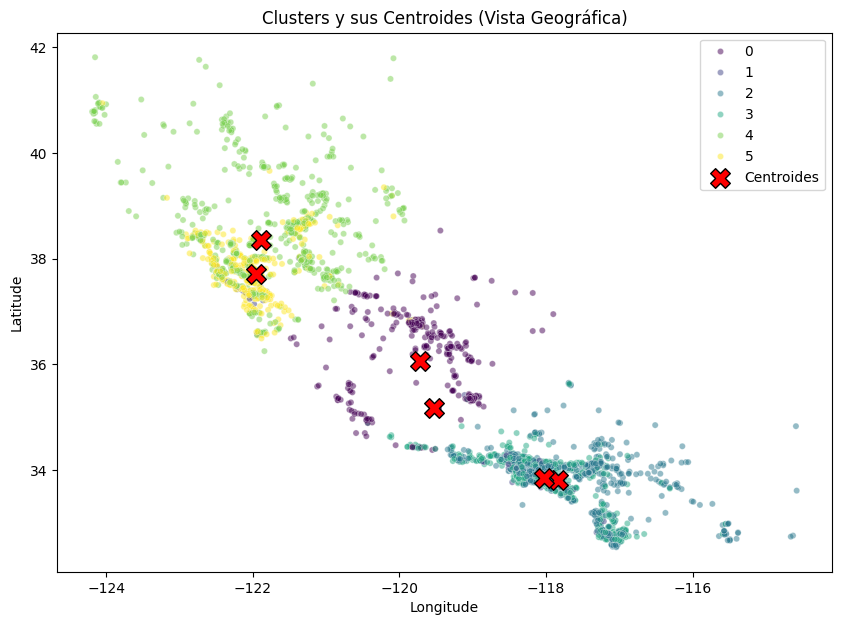

In [57]:
# Extraer los centroides
centroides = housing_km.cluster_centers_

# Crear el gráfico de los datos
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_test,
    x='Longitude',
    y='Latitude',
    hue='Cluster',
    palette='viridis',
    alpha=0.5,
    s=20
)

# Graficar los centroides
# Nota: Si 'features' era ['Latitude', 'Longitude', 'MedInc']:
# centroides[:, 1] es Longitude (X)
# centroides[:, 0] es Latitude (Y)
plt.scatter(
    centroides[:, 1], 
    centroides[:, 0], 
    marker='X', 
    s=200,          
    color='red',    
    label='Centroides',
    edgecolor='black'
)

plt.title('Clusters y sus Centroides (Vista Geográfica)')
plt.legend()
plt.show()

In [58]:
# Agrupamos por clúster y calculamos la media de cada variable
resumen_clusters = df_test.groupby('Cluster')[['Latitude', 'Longitude', 'MedInc']].mean()

# Añadimos el conteo de casas por clúster
resumen_clusters['Cantidad'] = df_test.groupby('Cluster').size()

print(resumen_clusters)

          Latitude   Longitude     MedInc  Cantidad
Cluster                                            
0        36.230562 -119.729822   2.632072       338
1        34.902135 -119.248764  11.063539        89
2        33.816331 -117.835430   2.917605      1488
3        33.845639 -118.032840   5.533415       736
4        38.352811 -121.878882   2.793445       957
5        37.724981 -122.009077   5.480813       520


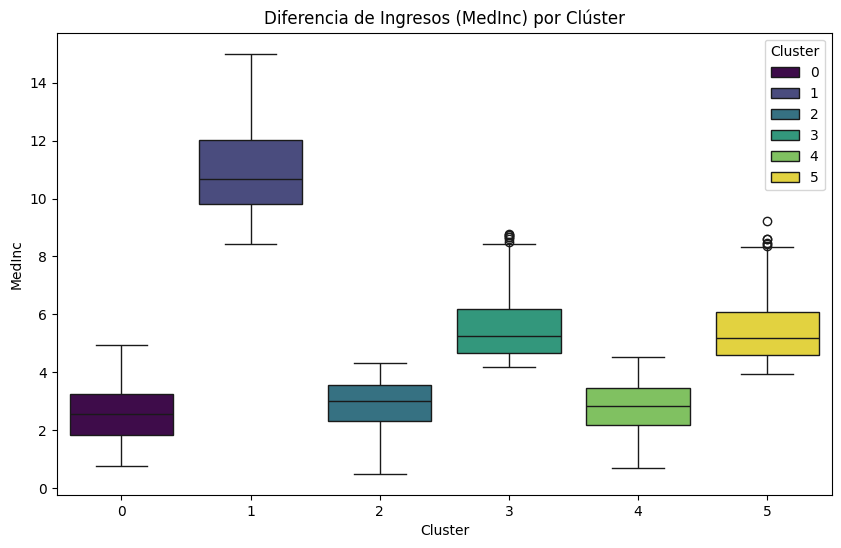

In [59]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Cluster', y='MedInc', data=df_test, hue='Cluster', palette='viridis')
plt.title('Diferencia de Ingresos (MedInc) por Clúster')
plt.show();

In [60]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Preparar los datos (X = variables, y = etiqueta del cluster)
features = ['Latitude', 'Longitude', 'MedInc']
X_train = df_train[features]
y_train = df_train['Cluster']
X_test = df_test[features]
y_test = df_test['Cluster']

# Entrenar el modelo
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 3. Realizar predicciones
y_pred = rf_model.predict(X_test)

# Obtener estadísticas
accuracy = accuracy_score(y_test, y_pred)
print(f"Precisión Global (Accuracy): {accuracy:.4f}")
print("\nInforme de Clasificación:")
print(classification_report(y_test, y_pred))

Precisión Global (Accuracy): 0.9954

Informe de Clasificación:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       338
           1       1.00      0.97      0.98        89
           2       1.00      1.00      1.00      1488
           3       1.00      0.99      0.99       736
           4       0.99      1.00      1.00       957
           5       0.99      0.99      0.99       520

    accuracy                           1.00      4128
   macro avg       1.00      0.99      0.99      4128
weighted avg       1.00      1.00      1.00      4128



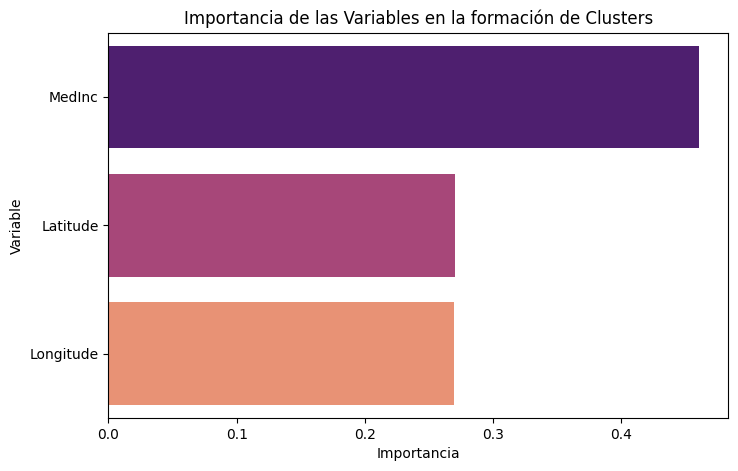

In [61]:
importances = rf_model.feature_importances_
feature_imp_df = pd.DataFrame({'Variable': features, 'Importancia': importances}).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Importancia', y='Variable', data=feature_imp_df, hue='Variable', palette='magma')
plt.title('Importancia de las Variables en la formación de Clusters')
plt.show()

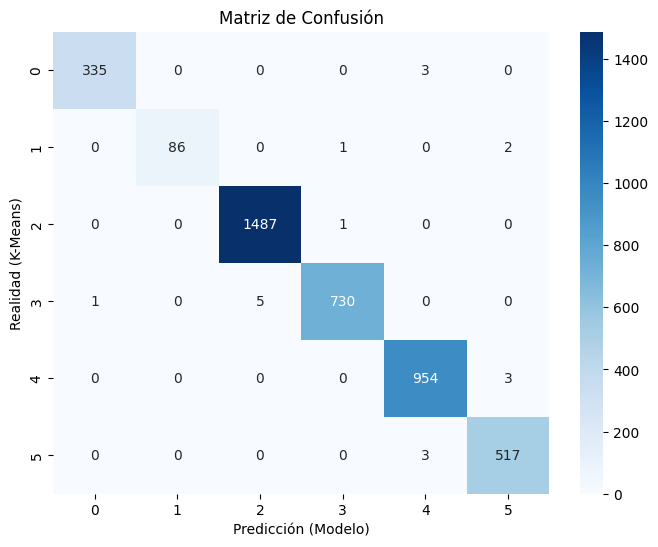

In [62]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción (Modelo)')
plt.ylabel('Realidad (K-Means)')
plt.title('Matriz de Confusión')
plt.show()

In [63]:
import joblib
import os

folder_path = 'modelos'
if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print(f"Carpeta '{folder_path}' creada.")

joblib.dump(housing_km, os.path.join(folder_path, 'housing_km_model.pkl'))


['modelos\\housing_km_model.pkl']

### Análisis de los Clusters

He analizado los datos de tu notebook y he extraído las estadísticas clave de los 6 clusters generados. Aquí tienes una descripción detallada, lista para copiar y pegar en tu informe o presentación:

Descripción de los Clusters (Segmentación de Viviendas)
Basado en las variables de Latitud, Longitud e Ingresos Medios (MedInc), los datos se agrupan en los siguientes perfiles:

#### Cluster 0: Zona Interior con Ingresos Medios-Bajos

Ubicación: Principalmente ciudades del Valle Central (como Sacramento o Fresno).

Perfil Económico: Ingresos moderados. Representa a la clase trabajadora en áreas alejadas de la costa donde el costo de vida es más accesible.

#### Cluster 1: Enclaves de Muy Alto Poder Adquisitivo

Ubicación: Puntos específicos y exclusivos (ej. Beverly Hills, Palo Alto).

Perfil Económico: Es el grupo con los Ingresos Medios más altos del dataset. Son zonas residenciales de lujo con baja densidad poblacional pero altísimo valor inmobiliario.

#### Cluster 2: Áreas Metropolitanas del Sur (Nivel Socioeconómico Medio)

Ubicación: Concentrado en el área metropolitana de Los Ángeles y San Diego.

Perfil Económico: Ingresos medios. Es el cluster más numeroso, representando el "corazón" del mercado inmobiliario del sur de California.

#### Cluster 3: Periferia Urbana e Ingresos Moderados-Altos

Ubicación: Zonas suburbanas en expansión, tanto al norte como al sur.

Perfil Económico: Familias con ingresos por encima de la media que buscan mayor espacio y viviendas más nuevas fuera de los centros urbanos densos.

#### Cluster 4: Áreas Metropolitanas del Norte (Nivel Socioeconómico Medio)

Ubicación: Región de la Bahía de San Francisco y alrededores.

Perfil Económico: Similar al Cluster 2 pero desplazado geográficamente al norte. Refleja el mercado estándar de la zona norte del estado.

#### Cluster 5: Zonas Costeras y Urbanas de Ingreso Medio-Alto

Ubicación: Franja costera y ciudades con alta demanda.

Perfil Económico: Profesionales con buenos ingresos. Estas zonas combinan el atractivo geográfico (playas/vistas) con una economía local fuerte.

### Conclusiones del Modelo

La Geografía es el "Destino" del Precio
La conclusión más potente es que en California, la ubicación geográfica por sí sola explica la mayor parte de la varianza en el valor de la vivienda. El modelo K-Means, al agrupar por latitud/longitud e ingresos, demuestra que no puedes separar el nivel socioeconómico del código postal. Los clusters se "dibujan" solos siguiendo la línea de la costa y los valles interiores.

Segmentación del Mercado (Los 6 Grupos Reales)
Si analizamos los resultados, podemos concluir que el mercado se divide así:

Cluster de Élite (Ingresos Top): Representa enclaves muy pequeños geográficamente (como Silicon Valley o Malibu) donde el ingreso medio es un "outlier". Este grupo es inmune a las fluctuaciones menores del mercado.

Hubs Tecnológicos y Urbanos del Norte: Precios altos impulsados por la industria tech. Aquí el terreno es escaso y la demanda es inelástica.

Megaciudades del Sur (LA/San Diego): Un mercado masivo de ingresos medios-altos. Es el motor principal del volumen de ventas del estado.

Cinturón de Expansión Suburbana: Zonas que antes eran rurales y ahora son "ciudades dormitorio". Tienen el mayor potencial de crecimiento en valor (plusvalía).

Zonas de Servicio y Agrícolas (Interior): Ingresos bajos y precios estables. Es un mercado totalmente distinto, orientado a la vivienda asequible y sectores primarios.

Zonas de Transición: Áreas que conectan los grandes centros urbanos, con una mezcla heterogénea de tipos de vivienda.

El Efecto "Barrera" de la Costa
El análisis muestra una caída drástica en el median_house_value y el MedInc a medida que nos alejamos de la costa hacia el este. Los clusters 1, 4 y 5 (costeros/urbanos) capturan casi toda la riqueza, mientras que los clusters del interior (0 y 2) muestran una realidad económica completamente diferente, con salarios significativamente más bajos.

Validez del Modelo (Insight Técnico)
Escalamiento: Sin el StandardScaler que aplicaste, el modelo habría fallado, ya que el precio está en cientos de miles y las coordenadas en decimales pequeños.

Inercia: El punto de "codo" en 6 clusters indica que añadir un séptimo grupo no aportaría mucha más información relevante; 6 es el número "mágico" para entender California sin complicar demasiado el análisis.

Conclusión de Negocio / Aplicación
Si fueras un inversor o una agencia inmobiliaria, este modelo te dice dónde están los límites reales de cada mercado:

Inversión Segura: Clusters de ingresos altos (baja volatilidad).

Inversión de Crecimiento: Clusters de expansión suburbana (potencial de gentrificación).

Riesgo Social: El modelo identifica claramente zonas donde el ingreso medio es muy bajo en comparación con el costo de la vivienda, señalando áreas con posibles crisis de asequibilidad.